In [2]:
path = '../data/hospital_patients_real_world.csv'
import pandas as pd
import seaborn as sns

In [3]:
# Dados do dataset
df = pd.read_csv(path)

In [4]:
df.head(100)

,PatientID,Age,Gender,Diagnosis,AdmissionDate,DischargeDate,HospitalID
0,PN-2021066,7.0,Other,Myocardial Infarction,2024-03-23,2024-03-29,HOSP-65
1,PN-4606019,36.0,Other,Pneumonia,2024-08-01,2024-08-07,HOSP-79
2,PN-2594016,70.0,Other,Influenza,2024-11-16,2024-11-23,HOSP-27
3,PN-6906914,90.0,Unknown,Acute Bronchitis,2025-07-05,2025-07-10,HOSP-64
4,PN-4656204,0.0,Female,Type 2 Diabetes,2023-08-30,2023-08-31,HOSP-31
...,...,...,...,...,...,...,...
95,PN-1978637,16.0,Other,Myocardial Infarction,2023-08-30,2023-09-06,HOSP-53
96,PN-2900457,80.0,NaN,Urinary Tract Infection,2023-10-09,2023-10-16,HOSP-26
97,PN-4689749,82.0,Other,Chronic Kidney Disease,2025-02-21,2025-02-27,HOSP-65
98,PN-6659337,47.0,Other,Atrial Fibrillation,2023-11-05,2023-11-14,HOSP-43


In [5]:
# Informações das colunas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      5000 non-null   str    
 1   Age            4650 non-null   float64
 2   Gender         4650 non-null   str    
 3   Diagnosis      4650 non-null   str    
 4   AdmissionDate  5000 non-null   str    
 5   DischargeDate  5000 non-null   str    
 6   HospitalID     5000 non-null   str    
dtypes: float64(1), str(6)
memory usage: 273.6 KB


In [6]:
df.isnull().sum()

PatientID          0
Age              350
Gender           350
Diagnosis        350
AdmissionDate      0
DischargeDate      0
HospitalID         0
dtype: int64

In [7]:
df.isna().all(axis=1).any()
# Não existem linhas 100% nulas

np.False_

In [8]:
df['Gender'].unique()
# Possui nan que podem ser agregadas a categoria Unknown

<StringArray>
['Other', 'Unknown', 'Female', 'Male', nan]
Length: 5, dtype: str

In [9]:
df['Gender'].value_counts()
# Grande volume de Unknown na coluna

Gender
Other      1223
Unknown    1163
Female     1153
Male       1111
Name: count, dtype: int64

In [10]:
df['Diagnosis'].unique()
# Existem palavras em caixa alta que já existem em caixa baixa

<StringArray>
[  'Myocardial Infarction',               'Pneumonia',
               'Influenza',        'Acute Bronchitis',
         'Type 2 Diabetes',         'Gastroenteritis',
 'Urinary Tract Infection',          'Diverticulitis',
          'Cholelithiasis',          'CHOLELITHIASIS',
            'HYPERTENSION',  'Chronic Kidney Disease',
     'Atrial Fibrillation',                  'Asthma',
                       nan,          'Osteoarthritis',
            'Hypertension', 'URINARY TRACT INFECTION',
               'INFLUENZA',         'GASTROENTERITIS',
         'TYPE 2 DIABETES',                  'ASTHMA',
               'PNEUMONIA',          'DIVERTICULITIS',
        'ACUTE BRONCHITIS',  'CHRONIC KIDNEY DISEASE',
     'ATRIAL FIBRILLATION',   'MYOCARDIAL INFARCTION',
          'OSTEOARTHRITIS']
Length: 29, dtype: str

<Axes: ylabel='Age'>

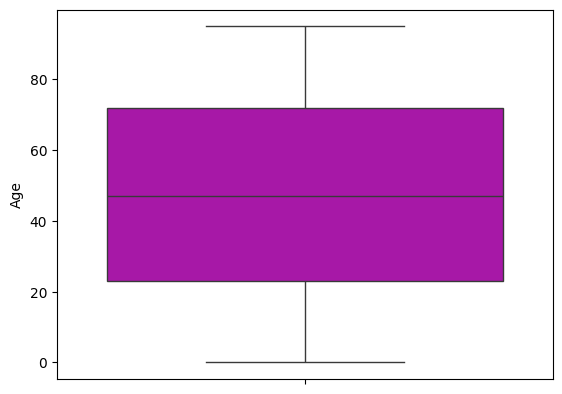

In [11]:
sns.boxplot(df.Age, color = 'm')
# Não possui outliers

In [14]:
mask = df['AdmissionDate'] > df['DischargeDate']

df_invalid = df[mask]
# Existem datas de alta antes de datas de entrada no hospital

In [17]:
percentual = len(df_invalid) / len(df) * 100

percentual

# cerca de 3% dos dados estão com as datas inconsistente

3.0